# Illumination for Arwen beam per beam

In [34]:
import numpy as np
import scipy as sp
import pandas as pd
from helpers import rwbeams, rwhist
from scipy.integrate import quad
from scipy.optimize import root_scalar

import matplotlib.pyplot as plt

## Data Extraction

In [35]:
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")

thetas = df_omega['LAT_rad'].values
energies = df_omega['energy'].values

# Number of beam verification
num_beams = len(df_omega)

## Parameter definition

In [36]:
num_beams = len(df_omega)
thetas = df_omega['LAT_rad'].values
energies = df_omega['energy'].values

R_injection = 1.0           # Injection sphere (m)
my_defocus =    0.5 # Defocus of 0.05 mm converted to meters
num_micro_rays = 150        # Number of micro-rays per beam (N)

# Laser spatial profile parameters
# (Adjust if your internship supervisor provided specific values for OMEGA)
f_number = 1.65 / (2.0 * 0.14) 
cone_angle = np.arctan(1.0 / (2.0 * f_number)) # Cone half-angle
s_param = cone_angle / 2.0                     # Spreading parameter (typical)
beta_param = 3.0                               # Super-Gaussian profile, flat at the center

## Beam per beam

Definition of the intensity function

In [37]:
def super_gaussian_intensity(theta_ref, s, beta):
    return lambda x: np.exp(-np.abs((x - theta_ref) / s)**beta) * np.sin(x)  # Include sin(theta) for proper weighting in spherical coordinates

Calculating the angles for one beam

In [38]:
def generate_beam_angles(beam, num_rays,):

    func_dist = lambda x: np.exp(-np.abs((x - beam['theta_ref']) / beam['scale'])**beam['beta']) * np.sin(x)

    num_sectors = 2 * num_rays + 1

    total_energy, _ = quad(func_dist, beam['theta_lo'], beam['theta_hi'])
    assert total_energy > 0, "Total energy must be positive. Check the distribution function and integration limits."
    energy_per_sector = total_energy / num_sectors

    print(f"Total energy in beam: {total_energy:.4e}, Energy per sector: {energy_per_sector:.4e}")
    
    thetas_edges = [beam['theta_lo']] 
    
    for i in range(1, 2 * num_rays + 1):
        prev_theta = thetas_edges[-1]
        
        def F(current_theta):
            integral, _ = quad(func_dist, prev_theta, current_theta)
            return energy_per_sector - integral
        
        # Solving F(theta) = 0
        theta_delta = 1.e-5 * np.abs(beam['theta_hi'] - beam['theta_lo'])  # Small delta to ensure we are in the correct range
        result = root_scalar(F, bracket=[prev_theta, beam['theta_hi'] + theta_delta], method='brentq')
        thetas_edges.append(result.root)
        
    # Extracting the centers (odd indices)
    return np.array(thetas_edges)[1::2]

def generate_beam_rays(beam, num_rays, R = 1.0, ):
    theta = generate_beam_angles(beam, num_rays,)
    xs = R * np.sin(theta)
    zs = R * np.cos(theta)
    us = beam['focus'][0] - xs
    ws = beam['focus'][1] - zs
    return np.column_stack((xs, zs, us, ws))

In [39]:
beam = { 
  'theta_ref': np.pi/4, 
  'theta_lo': np.pi/4 - np.pi/4,
  'theta_hi': np.pi/4 + np.pi/4,
  'scale': np.pi/8.,
  'beta': beta_param,
  'energy': 1., 
  'focus': np.array([0.0, 0.0])
} 

thetas_test = generate_beam_angles(beam, 100, )

Total energy in beam: 4.8181e-01, Energy per sector: 2.3970e-03


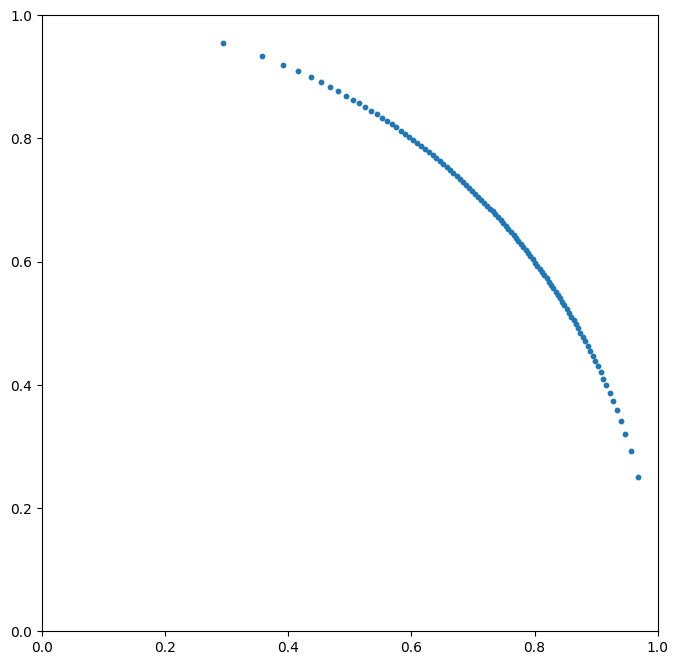

In [40]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, 1.)
ax.set_ylim(0, 1.)

ax.set_aspect('equal')
ax.scatter(np.sin(thetas_test), np.cos(thetas_test), s=10)  # Plotting theta vs intensity (which is not calculated here, just for visualization)

In [41]:
rays_test = generate_beam_rays(beam, 200, R=1.0, )

Total energy in beam: 4.8181e-01, Energy per sector: 1.2015e-03


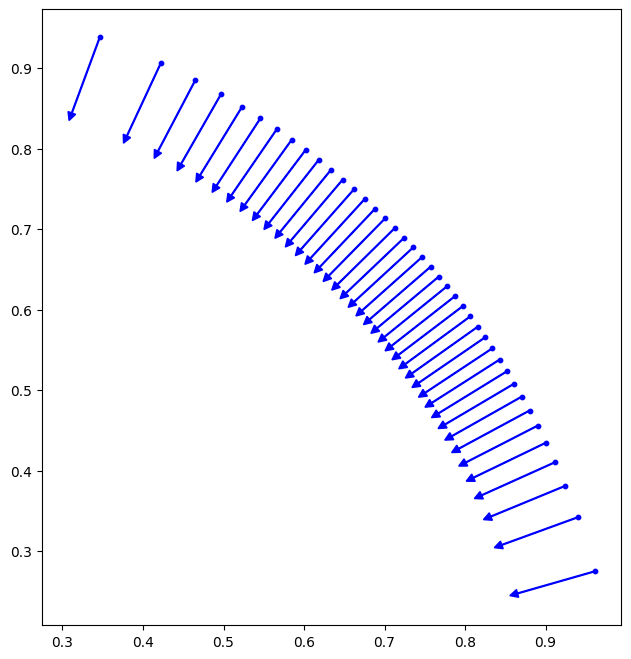

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

num_rays_to_plot = 40
inc = len(rays_test) // num_rays_to_plot
begin = inc // 2

ax.set_aspect('equal')
for ray in rays_test[begin::inc]:
    ax.scatter(ray[0], ray[1], s=10, c='blue')  # Plotting r_start vs z_start
    # print arrow stating at (ray[0], ray[1]) with direction (ray[2], ray[3])
    ax.arrow(ray[0], ray[1], ray[2]*0.1, ray[3]*0.1, head_width=0.01, head_length=0.01, fc='blue', ec='blue')

Calculating the angles for the 60 beams 

In [43]:
import numpy as np

def generate_all_macro_rays(thetas, energies, cone_angle, N_total, s_param, beta_param, my_defocus, R_injection):
    """
    Discretizes all the configuration beams into equal-energy sub-rays globally.
    Returns a dictionary containing the starting coordinates, normalized directions, and energy of each ray.
    """

    # validation
    assert len(thetas) == len(energies), "The number of angles and energies must match."

    tous_r_start = []
    tous_z_start = []
    tous_dir_r = []
    tous_dir_z = []
    tous_energies = []
    
    # --- NOUVEAUTÉ : Calcul de l'énergie totale ---
    energie_totale = sum(energies)
    
    for theta_ref, energie_faisceau in zip(thetas, energies):
        
        # --- NOUVEAUTÉ : Application de la formule du maître de stage ---
        # 1. Calcul du poids (w)
        w = energie_faisceau / energie_totale
        
        # 2. Nombre de sous-rayons pour CE faisceau (N_i) arrondi au supérieur
        N_i = int(np.ceil(N_total * w))
        
        # On recrée le dictionnaire 'beam' pour le faisceau actuel
        beam = {
            'theta_ref': theta_ref,
            'theta_lo': theta_ref - cone_angle,
            'theta_hi': theta_ref + cone_angle,
            'scale': s_param,
            'beta': beta_param,
            'energy': energie_faisceau,
            'focus': np.array([0.0, 0.0])
        }
        
        # On passe le bon dictionnaire 'beam' et le N_i calculé
        thetas_sous_rayons = generate_beam_rays(beam, N_i, R=1.0)
        
        # The focal point with defocus is common to all sub-rays of this beam
        r_target = -my_defocus * np.sin(theta_ref)
        z_target = -my_defocus * np.cos(theta_ref)
        
        # --- VECTOR CALCULATIONS ---
        # Simultaneous calculation for all sub-rays of the current beam
        r_start = R_injection * np.sin(thetas_sous_rayons)
        z_start = R_injection * np.cos(thetas_sous_rayons)
        
        # Direction vectors
        dir_r = r_target - r_start
        dir_z = z_target - z_start
        
        # Vector normalization
        norm = np.sqrt(dir_r**2 + dir_z**2)
        dir_r /= norm
        dir_z /= norm
        
        # Equal energy distribution across the array (using N_i instead of fixed number)
        energie_par_rayon = np.full_like(thetas_sous_rayons, energie_faisceau / N_i)
        
        # Recording by extending the global lists
        tous_r_start.extend(r_start)
        tous_z_start.extend(z_start)
        tous_dir_r.extend(dir_r)
        tous_dir_z.extend(dir_z)
        tous_energies.extend(energie_par_rayon)
        
    # Final conversion to a dictionary of numpy arrays
    return {
        'r_start': np.array(tous_r_start),
        'z_start': np.array(tous_z_start),
        'dir_r': np.array(tous_dir_r),
        'dir_z': np.array(tous_dir_z),
        'energies': np.array(tous_energies)
    }

In [44]:
# On définit le nombre total de rayons souhaité pour toute la simulation
# (10 000 comme sur la note de ton maître de stage)
N_total = 10000 

print(f'Number of beams: {len(thetas)}, Target total rays: {N_total}')

# On utilise la fonction mise à jour
rays_dict = generate_all_macro_rays(
    thetas=thetas, 
    energies=energies, 
    cone_angle=cone_angle, 
    N_total=N_total,         # Remplacement ici
    s_param=s_param, 
    beta_param=beta_param, 
    my_defocus=my_defocus, 
    R_injection=R_injection
)

# Exemple pour vérifier que tout marche bien :
# Le nombre réel généré peut être légèrement supérieur à N_total à cause du np.ceil() qui arrondit au supérieur
print(f"Nombre réel de rayons générés (Dimensions de r_start) : {rays_dict['r_start'].shape[0]}")

Number of beams: 60, Target total rays: 10000
Total energy in beam: 1.5246e-02, Energy per sector: 4.5510e-05
Total energy in beam: 1.5246e-02, Energy per sector: 4.5510e-05
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 6.9134e-02, Energy per sector: 2.063

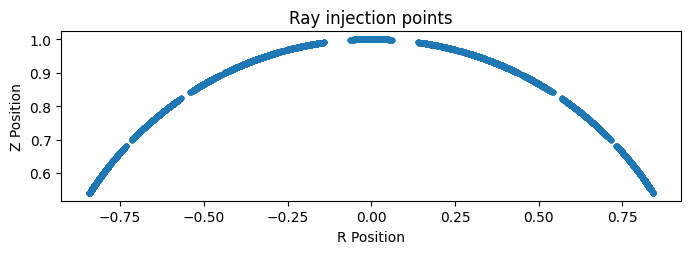

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_aspect('equal')

# No more for loop needed! We plot all points at once
ax.scatter(rays_dict['r_start'], rays_dict['z_start'], s=10)

# Some labels to keep it clean (optional but recommended)
ax.set_xlabel("R Position")
ax.set_ylabel("Z Position")
ax.set_title("Ray injection points")

plt.show()

## Analysis of the angle between u and x

## Creation of the txt file

In [46]:
# 1. On récupère le dictionnaire complet généré par la fonction
rays_dict = generate_all_macro_rays(
    thetas=thetas,
    energies=energies,
    cone_angle=cone_angle,
    N_total=N_total,         # L'argument a été mis à jour ici
    s_param=s_param,
    beta_param=beta_param,
    my_defocus=my_defocus,
    R_injection=R_injection
)



Total energy in beam: 1.5246e-02, Energy per sector: 4.5510e-05
Total energy in beam: 1.5246e-02, Energy per sector: 4.5510e-05
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 3.9221e-02, Energy per sector: 1.1708e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.1639e-02, Energy per sector: 1.5415e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 5.7229e-02, Energy per sector: 1.7083e-04
Total energy in beam: 6.9134e-02, Energy per sector: 2.0637e-04
Total energy in beam: 6.9134e-02, Energy

In [ ]:
file_name = 'rays_init_method_B.txt'

with open(file_name, 'w') as fd:
    
    # L'ajout de .flatten() "écrase" les dimensions superflues
    # pour garantir qu'on itère sur de purs nombres décimaux
    for r, z, dr, dz in zip(
        rays_dict['r_start'].flatten(), 
        rays_dict['z_start'].flatten(), 
        rays_dict['dir_r'].flatten(), 
        rays_dict['dir_z'].flatten()
    ):
        
        # Le formatage fonctionnera parfaitement maintenant
        line = f"{r:15.7e} {z:15.7e} {dr:15.7e} {dz:15.7e}\n"
        fd.write(line)

print(f"Success: The ARWEN input file '{file_name}' has been saved.")

Success: The ARWEN input file 'rays_init_method_B.txt' has been saved.


: 